In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Завантажуємо "чисті" дані опитування DOU, які ми отримали за допомогою Pandas та зберегли у CSV.

In [ ]:
path = "/content/drive/MyDrive/IT in Analytics/Python/Spring 2023/2022_dec_cleaned.csv"
dou = pd.read_csv(path, index_col=0, parse_dates=True)

In [ ]:
dou.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13315 entries, 2022-11-30 10:26:37 to 2023-01-09 11:38:00
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employment_type       13315 non-null  object 
 1   in_ukraine            13315 non-null  bool   
 2   region                11538 non-null  object 
 3   salary                13288 non-null  float64
 4   gender                13315 non-null  object 
 5   age                   13315 non-null  float64
 6   education             13315 non-null  object 
 7   scientific_degree     13204 non-null  object 
 8   english_level         13315 non-null  object 
 9   position              13315 non-null  object 
 10  title                 13315 non-null  object 
 11  use_code              4874 non-null   object 
 12  programming_language  9060 non-null   object 
 13  specialization        9059 non-null   object 
 14  area                  13315 non-nul

In [ ]:
dou = dou.dropna(subset=['salary'])
dou.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13288 entries, 2022-11-30 10:26:37 to 2023-01-09 11:38:00
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employment_type       13288 non-null  object 
 1   in_ukraine            13288 non-null  bool   
 2   region                11538 non-null  object 
 3   salary                13288 non-null  float64
 4   gender                13288 non-null  object 
 5   age                   13288 non-null  float64
 6   education             13288 non-null  object 
 7   scientific_degree     13177 non-null  object 
 8   english_level         13288 non-null  object 
 9   position              13288 non-null  object 
 10  title                 13288 non-null  object 
 11  use_code              4874 non-null   object 
 12  programming_language  9035 non-null   object 
 13  specialization        9034 non-null   object 
 14  area                  13288 non-nul

# Візуалізація у Matplotlib

Matplotlib --- вільна кросплатформова бібліотека мови Python з відкритим кодом, призначена для візуалізації даних за допомогою 2D-графіки. Підтримується також проста 3D-графіка та створення анімації. Перша версія бібліотеки вийшла у 2003 році. Офіційний сайт із документацією знаходиться за адресою https://matplotlib.org/.

Спочатку бібліотека розроблялася як додаток до пакету IPython для надання користувачеві MATLAB-подібного командного інтерфейсу для побудови графіків. Однак за підтримки та фінансування Space Telescope Science Institute пакет дуже швидко розвинувся у самостійний програмний продукт.

Бібліотека Matplotlib побудована на масивах NumPy, дотримуючись об'єктно-орієнтованої парадигми. Однак є і процедурний інтерфейс pylab. Як правило, використовується у зв'язці з іншими бібліотеками Python для наукової роботи та аналізу даних: NumPy, SciPy, Pandas та іншими.

Безперечною перевагою бібліотеки є те, що користувач може налаштовувати за власним бажанням будь-який аспект графіка --- від шрифтів на осях і розміру міток до колірних схем. На основі Matplotlib створено інші бібліотеки візуалізації з більш високорівневим та сучасним інтерфейсом (наприклад, Seaborn, ggpy, HoloViews, Altair).

Отримані за допомогою Matplotlib зображення можуть бути сконвертовані в безліч графічних форматів (як растрових, так і векторних) і використані як ілюстрації у публікаціях.

Історія Matplotlib: https://jakevdp.github.io/PythonDataScienceHandbook/04.00-introduction-to-matplotlib.html

Для підключення бібілотеки використовуємо один з варіантів:
```{Python}
import matplotlib as mpl
```
або, найчастіше,
```{Python}
import matplotlib.pyplot as plt
```

## Стилі графіків

Виведемо перелік доступних стилів (тем) графіків у Matplotlib.

In [ ]:
plt.style.available, len(plt.style.available)

(['Solarize_Light2',
  '_classic_test_patch',
  '_mpl-gallery',
  '_mpl-gallery-nogrid',
  'bmh',
  'classic',
  'dark_background',
  'fast',
  'fivethirtyeight',
  'ggplot',
  'grayscale',
  'seaborn-v0_8',
  'seaborn-v0_8-bright',
  'seaborn-v0_8-colorblind',
  'seaborn-v0_8-dark',
  'seaborn-v0_8-dark-palette',
  'seaborn-v0_8-darkgrid',
  'seaborn-v0_8-deep',
  'seaborn-v0_8-muted',
  'seaborn-v0_8-notebook',
  'seaborn-v0_8-paper',
  'seaborn-v0_8-pastel',
  'seaborn-v0_8-poster',
  'seaborn-v0_8-talk',
  'seaborn-v0_8-ticks',
  'seaborn-v0_8-white',
  'seaborn-v0_8-whitegrid',
  'tableau-colorblind10'],
 28)

Використаємо для подальшої роботи стиль `"fivethirtyeight"`, пов'язаний із відомим інтернет-виданням https://fivethirtyeight.com/, яке проводить статистичний аналіз даних про політику, науку, спорт тощо.

In [ ]:
plt.style.use('fivethirtyeight')

## Гістограми

Гістограми, як ми вже бачили із вами раніше, використовуються для візуалізації розподілу значень одновимірних кількісних даних. На гістограмі ми бачимо, скільки значень відповідної змінної припадає на певний інтервал (або `bin`, "корзинку"). Кількість таких "корзинок" можемо задати за допомогою параметру `bins`. За замовчуванням їх 10.

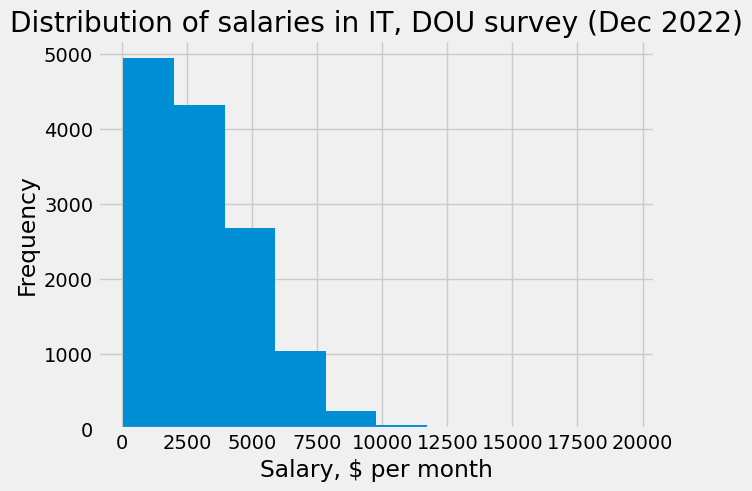

In [ ]:
plt.hist(dou['salary'])

plt.xlabel('Salary, $ per month')
plt.ylabel('Frequency')
plt.title('Distribution of salaries in IT, DOU survey (Dec 2022)')

plt.show()

Можемо змінити кількість "корзинок" (`bins`).

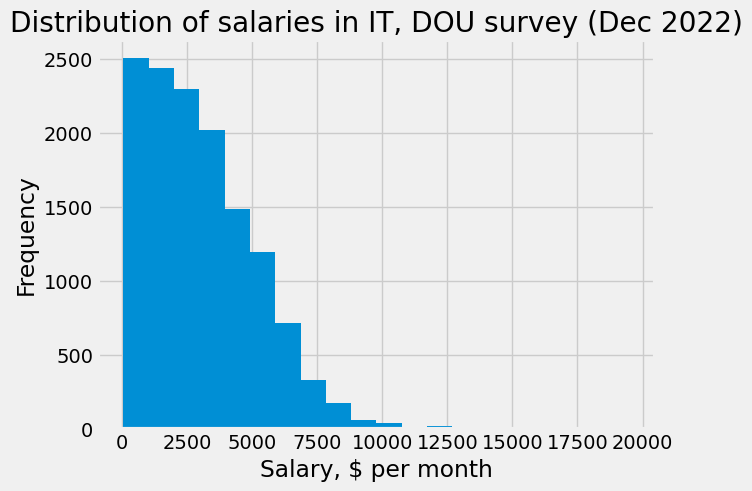

In [ ]:
plt.hist(dou['salary'], bins=20)

plt.xlabel('Salary, $ per month')
plt.ylabel('Frequency')
plt.title('Distribution of salaries in IT, DOU survey (Dec 2022)')

plt.show()

Гістограми показують, що розподіл значень не є нормальним (зміщений вліво). Чим більшим є рівень заробітної плати, тим менша кількість людей її отримує.

Спробуємо застосувати кастомні інтервали для зарплати, наприклад, такі сегменти:
* до 500 доларів на місяць
* від 500 до 1000
* від 1000 до 2000
* від 2000 до 5000
* від 5000 по 10000

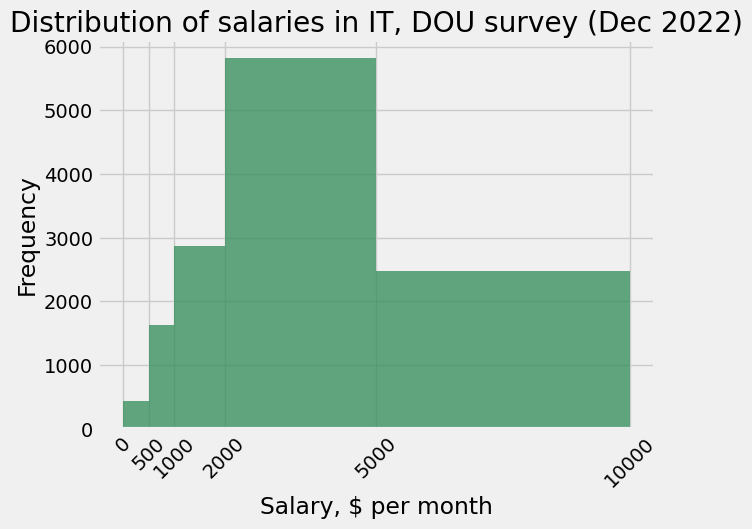

In [ ]:
plt.hist(dou['salary'], bins=[0, 500, 1000, 2000, 5000, 10000], color='SeaGreen', alpha=0.75)

plt.xticks(ticks=[0, 500, 1000, 2000, 5000, 10000], labels=[0, 500, 1000, 2000, 5000, 10000], rotation=45)

plt.xlabel('Salary, $ per month')
plt.ylabel('Frequency')
plt.title('Distribution of salaries in IT, DOU survey (Dec 2022)')

plt.show()

Отже, близько половини опитаних отримує зарплату в межах від 2000 до 5000 доларів на місяць. Додамо на графік також медіанну зарплату.

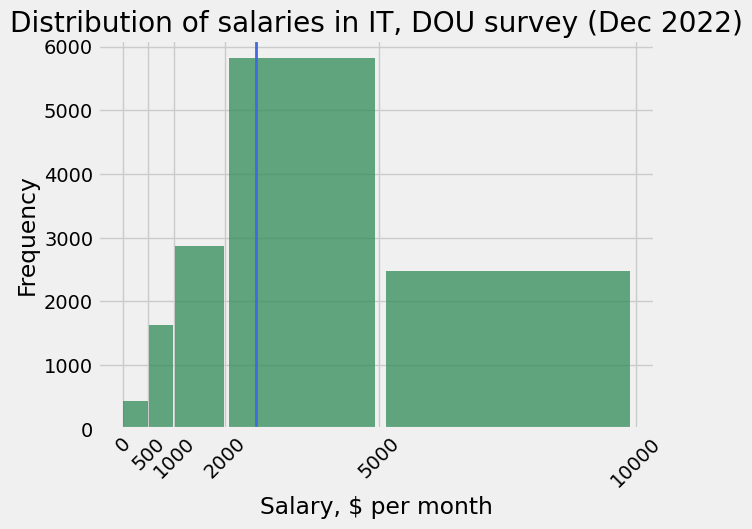

In [ ]:
plt.hist(dou['salary'], bins=[0, 500, 1000, 2000, 5000, 10000], color='SeaGreen', rwidth=0.95, alpha=0.75)
plt.axvline(x=dou['salary'].median(), linewidth=2, color='RoyalBlue')

plt.xticks(ticks=[0, 500, 1000, 2000, 5000, 10000], labels=[0, 500, 1000, 2000, 5000, 10000], rotation=45)

plt.xlabel('Salary, $ per month')
plt.ylabel('Frequency')
plt.title('Distribution of salaries in IT, DOU survey (Dec 2022)')

plt.show()

Ми використали додатково такі параметри для покращення оформлення графіка:
* `color` --- колір у вигляді HTML-назви (https://htmlcolorcodes.com/color-names/)
* `alpha` --- прозорість
* `rwidth` --- ширина стовпчика гістограми відносно ширини "корзини"
* `linewidth` --- товщина лінії
* `rotation` --- поворот мітки на осі координат на певний кут

### Гістограми для декількох груп

Спробуємо візуалізувати розподіл значень зарплати окремо для ІТ-спеціалістів, хто залишився в Україні та для тих, хто виїхав за кордон.

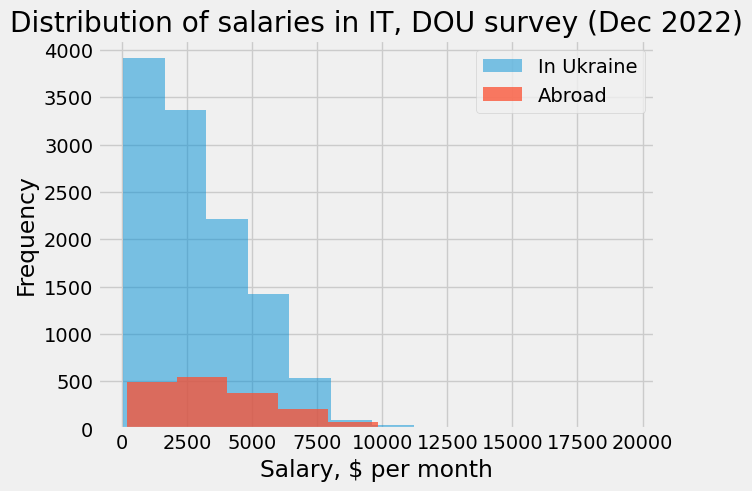

In [ ]:
plt.hist(dou[dou['in_ukraine']==True]['salary'], label='In Ukraine', alpha=0.5)
plt.hist(dou[dou['in_ukraine']==False]['salary'], label='Abroad', alpha=0.75)

plt.xlabel('Salary, $ per month')
plt.ylabel('Frequency')
plt.title('Distribution of salaries in IT, DOU survey (Dec 2022)')

plt.legend()

plt.show()

Для відображення легенди ми використали параметр `label` для гістограми та функцію `plt.legend()`.

Гістограма показує, що
* кількість тих, хто знаходиться за кордоном, значно менша порівняно з кількістю тих, хто залишився в Україні;
* у "високих" зарплатних сегментах (більше 5000 на місяць) доля тих, хто працює за кордоном, стає вищою.

Спробуємо тепер візуалізувати розподіл зарплат по тайтлам співробітників.

In [ ]:
dou['title'].value_counts()

Middle            4695
Senior            3394
Junior            2315
Team Lead          882
Немає тайтлу       571
Tech Lead          428
Manager            374
Head               250
Intern/Trainee     240
Architect          139
Name: title, dtype: int64

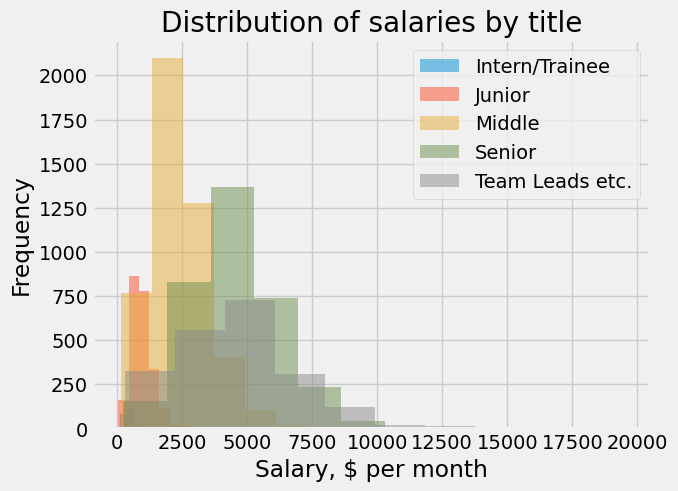

In [ ]:
intern_trainee = dou[dou['title']=='Intern/Trainee']['salary']
junior = dou[dou['title']=='Junior']['salary']
middle = dou[dou['title']=='Middle']['salary']
senior = dou[dou['title']=='Senior']['salary']
leaders = dou[dou['title'].isin(['Team Lead', 'Tech Lead', 'Manager', 'Head', 'Architect'])]['salary']

plt.hist(intern_trainee, label='Intern/Trainee', alpha=0.5)
plt.hist(junior, label='Junior', alpha=0.5)
plt.hist(middle, label='Middle', alpha=0.5)
plt.hist(senior, label='Senior', alpha=0.5)
plt.hist(leaders, label='Team Leads etc.', alpha=0.5)

plt.xlabel('Salary, $ per month')
plt.ylabel('Frequency')
plt.title('Distribution of salaries by title')

plt.legend()

plt.show()

Графік виходить малоінформативним через накладання гістограм одна на одну. Спробуємо зробити stacked-гістограму.

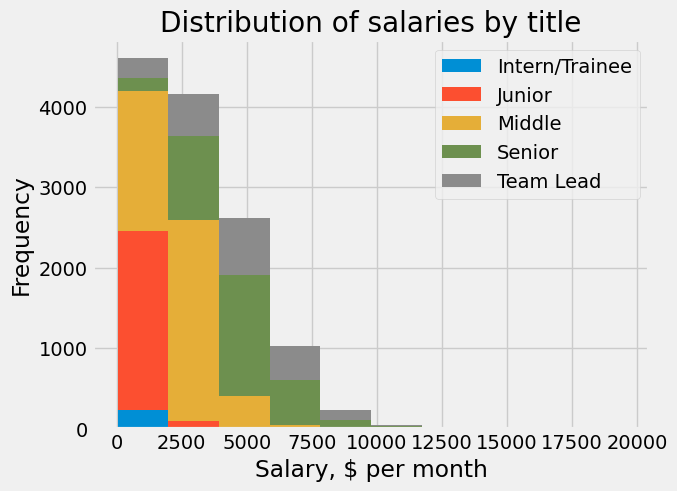

In [ ]:
intern_trainee = dou[dou['title']=='Intern/Trainee']['salary']
junior = dou[dou['title']=='Junior']['salary']
middle = dou[dou['title']=='Middle']['salary']
senior = dou[dou['title']=='Senior']['salary']
leaders = dou[dou['title'].isin(['Team Lead', 'Tech Lead', 'Manager', 'Head', 'Architect'])]['salary']

plt.hist([intern_trainee, junior, middle, senior, leaders], histtype='barstacked',
         label=['Intern/Trainee', 'Junior', 'Middle', 'Senior', 'Team Lead'])

plt.xlabel('Salary, $ per month')
plt.ylabel('Frequency')
plt.title('Distribution of salaries by title')

plt.legend()

plt.show()

Ситуація стала трохи кращою, проте все ще є проблеми:
* багато кольорів;
* маленька висота деяких фрагментів;
* важко порівняти візуально висоту стовпчиків, якщо вони не мають спільної початкової точки.

Спробуємо побудувати окремі гістограми на окремих графіках. Для цього користуємось `plt.subplots()`.

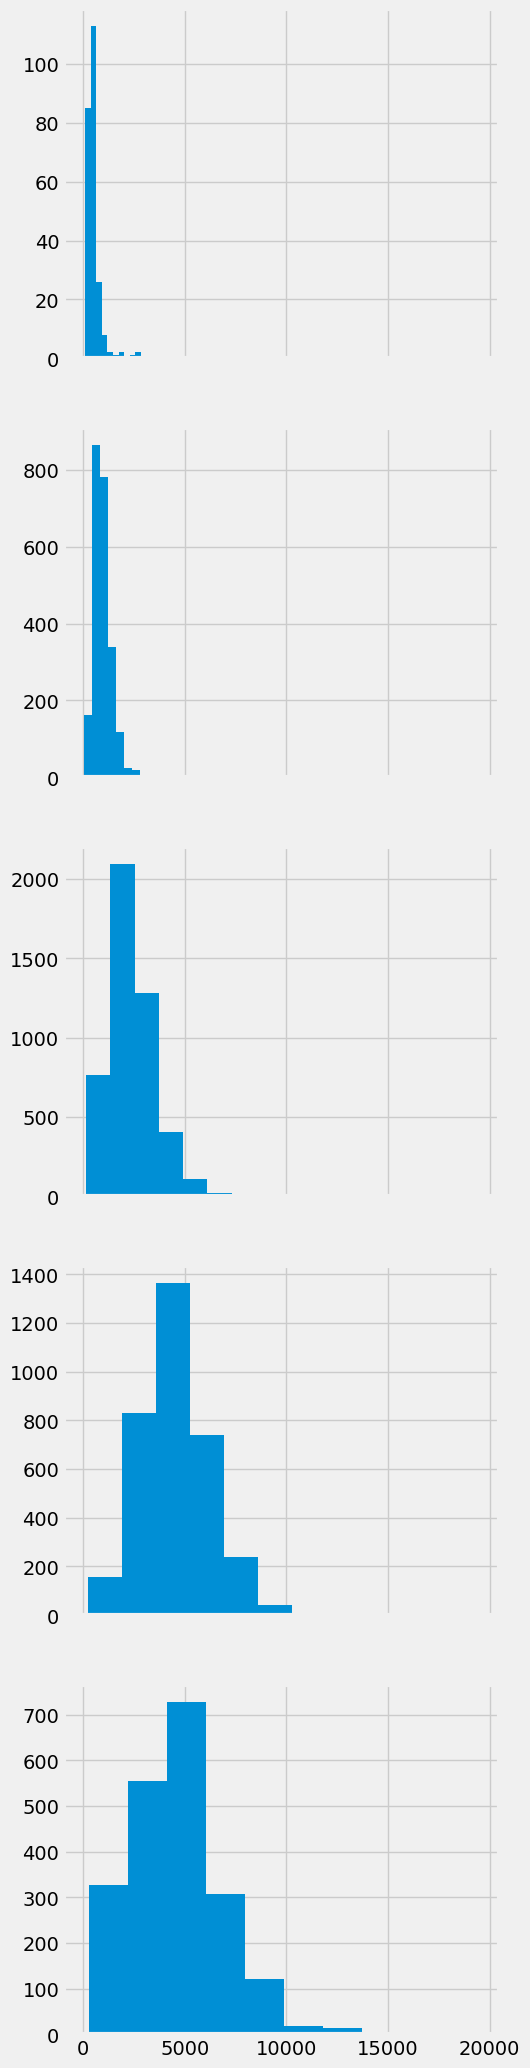

In [ ]:
fig, ax = plt.subplots(5, 1, sharex=True, figsize=(5, 25))

ax[0].hist(intern_trainee, label='Intern/Trainee')
ax[1].hist(junior, label='Junior')
ax[2].hist(middle, label='Middle')
ax[3].hist(senior, label='Senior')
ax[4].hist(leaders, label='Team Leads etc.')

plt.show()

## Boxplot, або "box and whiskers diagram", або "ящик з вусами"

Ще одним способом візуалізації розподілу кількісної змінної є boxplot, придуманий у 1970-х роках [Джоном Тьюкі](https://en.wikipedia.org/wiki/Box_plot).

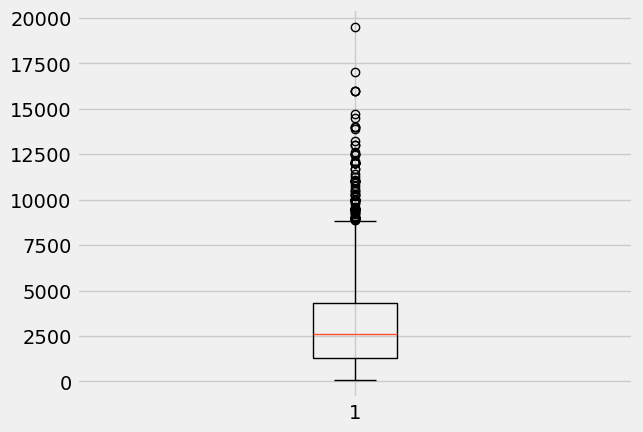

In [ ]:
plt.boxplot(dou['salary'])
plt.show()

Тепер побудуємо boxplot для кожного тайтла окремо.

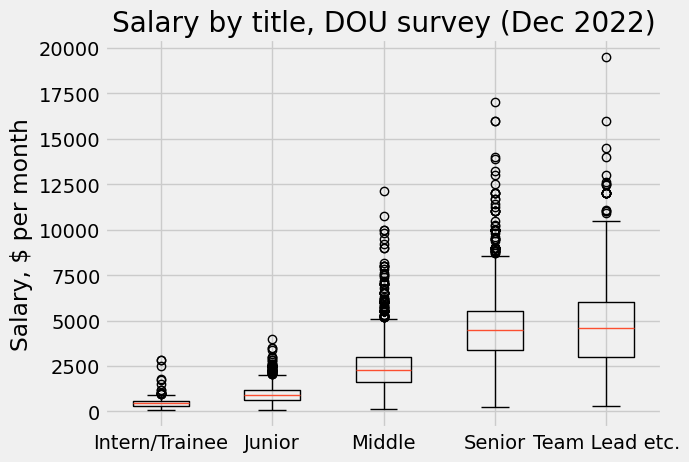

In [ ]:
plt.boxplot([intern_trainee, junior, middle, senior, leaders])

plt.xticks(ticks=[1, 2, 3, 4, 5], labels=['Intern/Trainee', 'Junior', 'Middle', 'Senior', 'Team Lead etc.'])
plt.ylabel('Salary, $ per month')
plt.title('Salary by title, DOU survey (Dec 2022)')

plt.show()

# Двовимірна візуалізація

In [ ]:
dou.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13288 entries, 2022-11-30 10:26:37 to 2023-01-09 11:38:00
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employment_type       13288 non-null  object 
 1   in_ukraine            13288 non-null  bool   
 2   region                11538 non-null  object 
 3   salary                13288 non-null  float64
 4   gender                13288 non-null  object 
 5   age                   13288 non-null  float64
 6   education             13288 non-null  object 
 7   scientific_degree     13177 non-null  object 
 8   english_level         13288 non-null  object 
 9   position              13288 non-null  object 
 10  title                 13288 non-null  object 
 11  use_code              4874 non-null   object 
 12  programming_language  9035 non-null   object 
 13  specialization        9034 non-null   object 
 14  area                  13288 non-nul

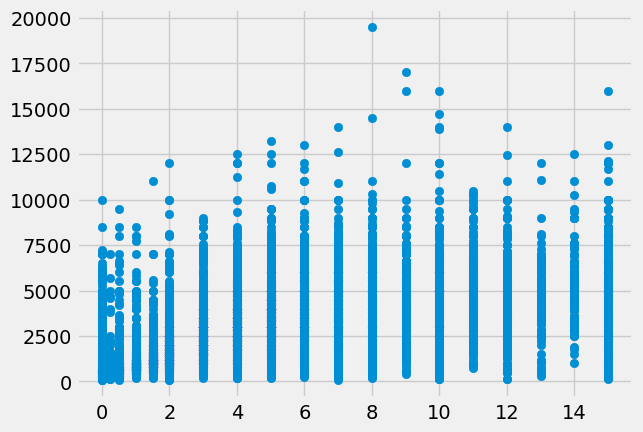

In [ ]:
plt.scatter(dou['work_experience'], dou['salary'])
plt.show()

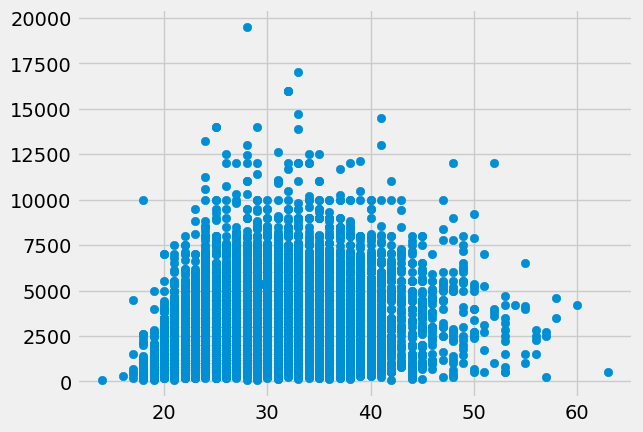

In [ ]:
plt.scatter(dou['age'], dou['salary'])
plt.show()

In [ ]:
title_order = ['Intern/Trainee', 'Junior', 'Middle', 'Senior', 'Head', 'Manager',
               'Team Lead',	'Tech Lead', 'Architect', 'Немає тайтлу']
title_position = dou.pivot_table(index='position', columns='title', values='salary', aggfunc='count')
title_position.reindex(columns=title_order)

title,Intern/Trainee,Junior,Middle,Senior,Head,Manager,Team Lead,Tech Lead,Architect,Немає тайтлу
position,,,,,,,,,,
"Analyst (Business, Data, System)",7.0,101.0,177.0,98.0,3.0,6.0,27.0,3.0,1.0,62.0
Customer Success,2.0,4.0,11.0,2.0,2.0,8.0,5.0,NaN,NaN,14.0
DBA,NaN,3.0,6.0,11.0,NaN,NaN,3.0,3.0,NaN,1.0
"Data Science, Machine Learning, Big Data",10.0,64.0,83.0,66.0,3.0,2.0,13.0,10.0,NaN,37.0
"Designer / Artist (Graphic, UX/UI, Game, Artist, Sound etc.)",10.0,80.0,182.0,103.0,9.0,4.0,36.0,4.0,3.0,55.0
"DevOps, SRE",10.0,57.0,109.0,109.0,2.0,3.0,25.0,10.0,3.0,25.0
ERP/CRM,NaN,2.0,17.0,11.0,NaN,NaN,2.0,NaN,NaN,5.0
Game Developer / Programmer,4.0,46.0,57.0,22.0,NaN,NaN,5.0,4.0,1.0,21.0
HR/Recruiter,10.0,108.0,147.0,79.0,50.0,38.0,57.0,3.0,NaN,67.0


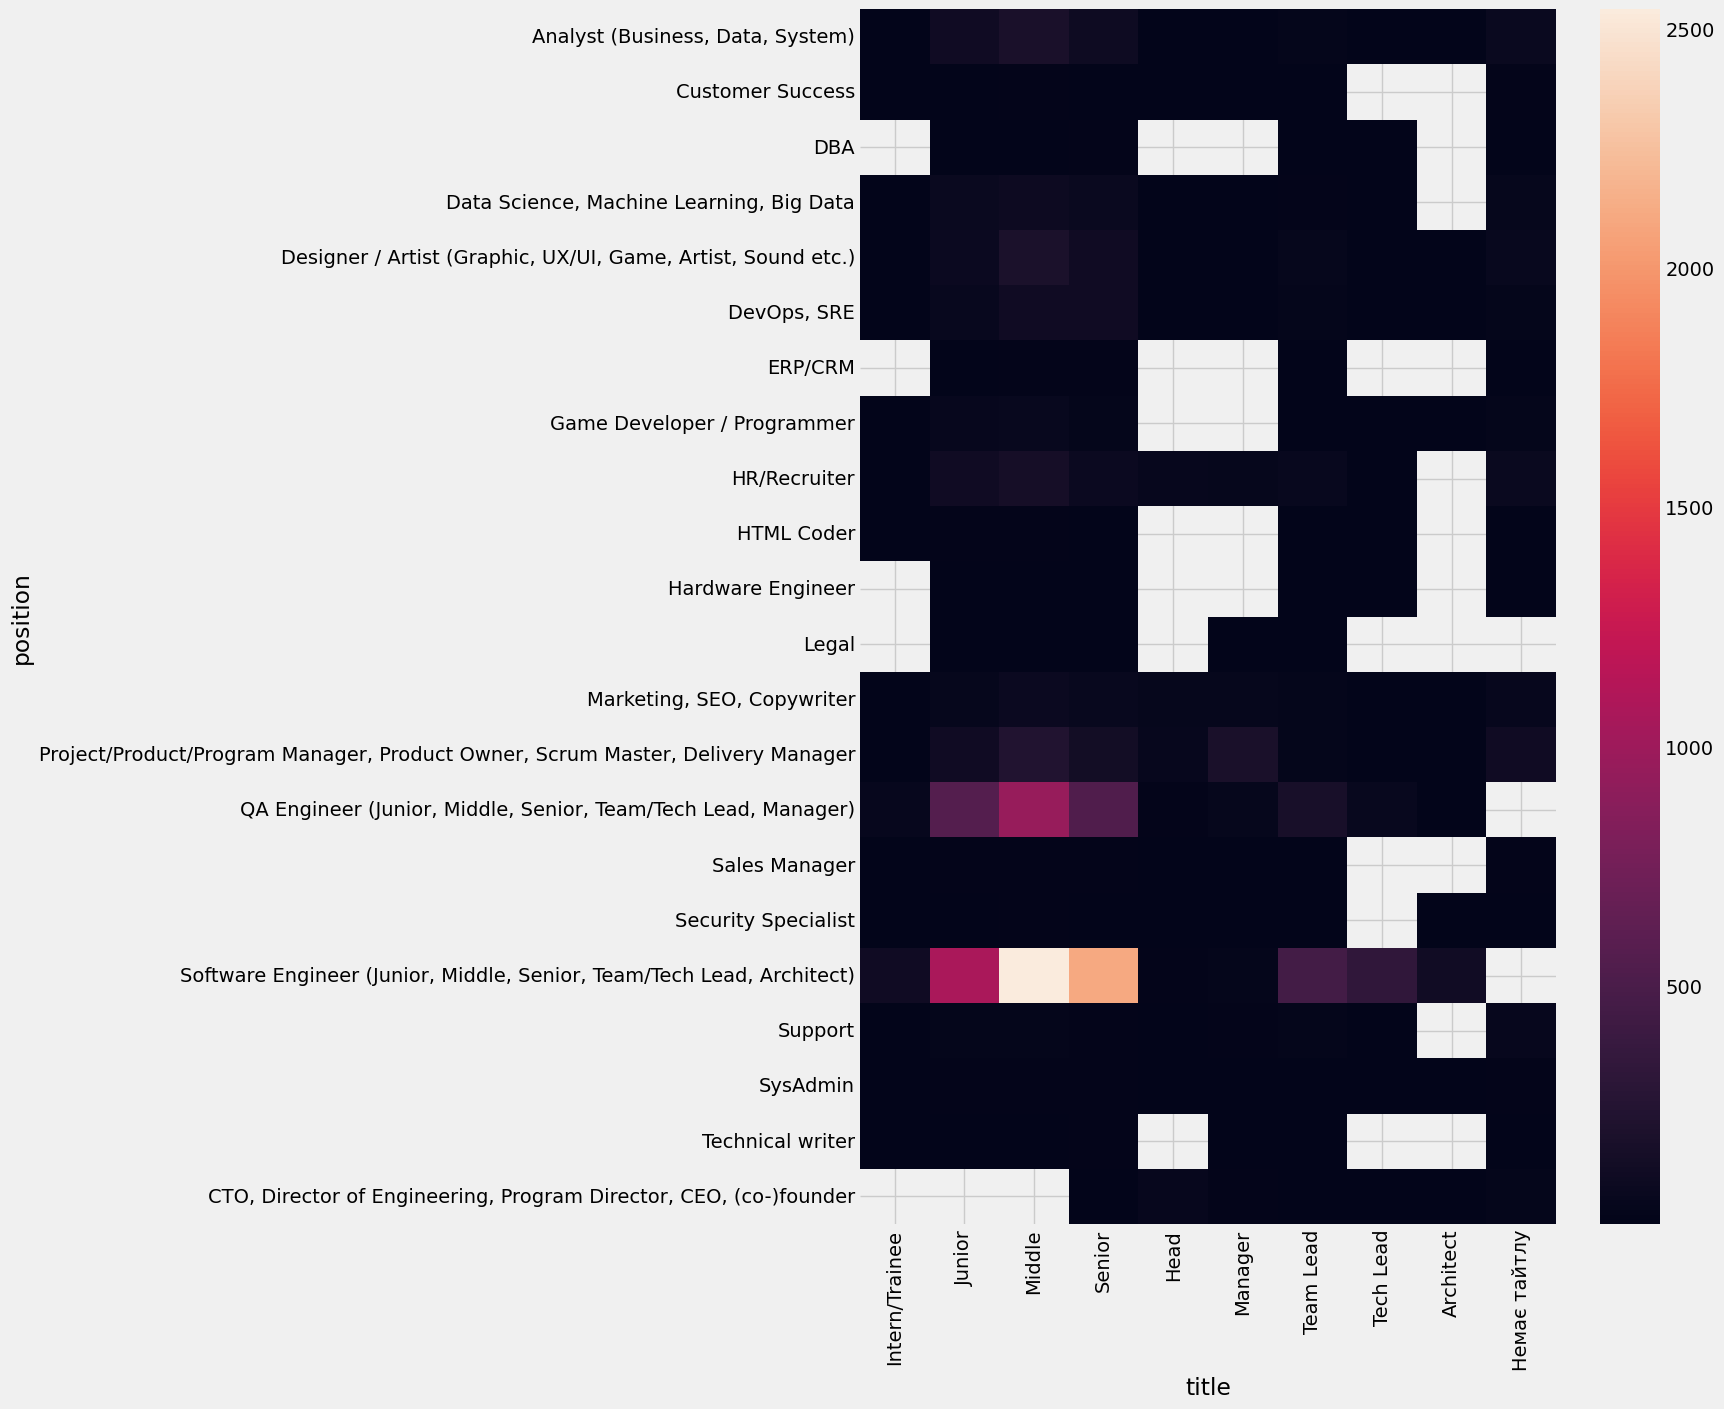

In [ ]:
fig, ax = plt.subplots(figsize=(10, 15))
sns.heatmap(title_position.reindex(columns=title_order))
plt.savefig("/content/drive/MyDrive/IT in Analytics/Python/Spring 2023/title_position_heatmap.png")
plt.show()

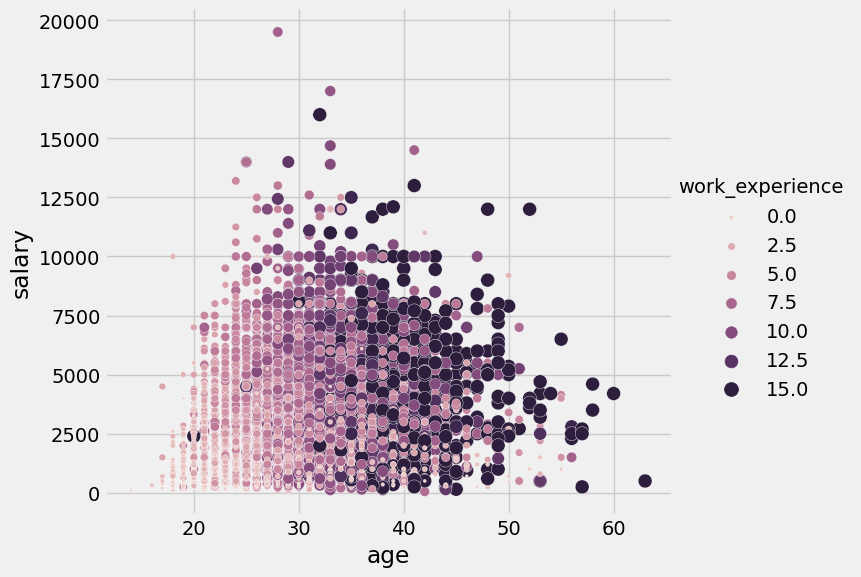

In [ ]:
sns.relplot(data=dou,
            x="age",
            y="salary",
            kind="scatter",
            hue="work_experience",
            size="work_experience", sizes=(5, 100),
            height=6, aspect=1.2
            )
plt.show()

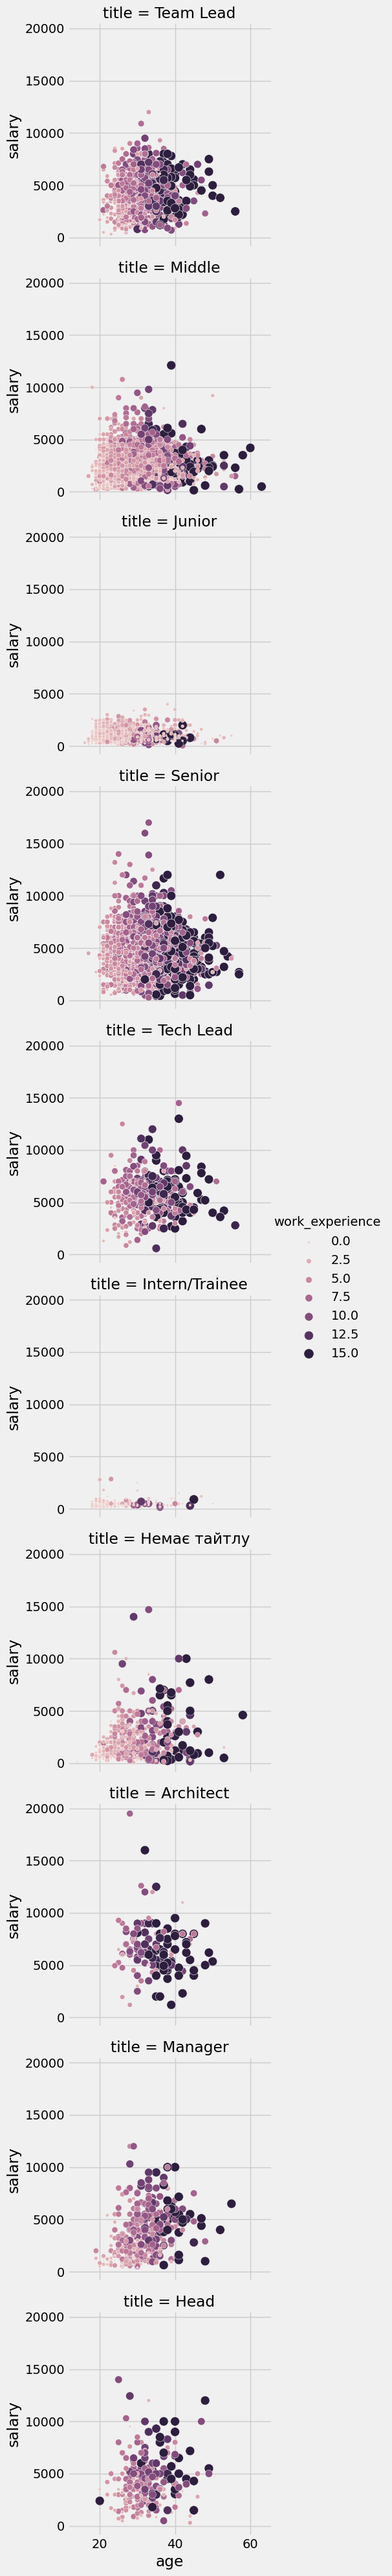

In [ ]:
sns.relplot(data=dou,
            x="age",
            y="salary",
            kind="scatter",
            hue="work_experience",
            size="work_experience", sizes=(5, 100),
            row="title",
            height=4, aspect=1.2
            )
plt.show()